## Week 1 Practice
----
- **Dataset: MNIST, CIFAR-10**
  - if use torchvision.datasets:
  - https://docs.pytorch.org/vision/stable/datasets.html
  - if use **Custom Dataset**:
  - https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
- **Model: Freely Select from torchvision library (e.g., VGG, ResNet)**
  - https://docs.pytorch.org/vision/main/models.html
- **Goal: Achieve over 80% accuracy on the test data**
  
*Env(cs231n_311): Python==3.11 | pytorch(CUDA 12.6) | torchvision | 

In [1]:
# [Import tools for custom datasets and models]
# Not to use 'from torchvision.datasets import MNIST, CIFAR10', Download Original Datasets and Make Custom Datasets
import os
import pandas as pd
import pickle
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.io import decode_image
import torchvision.transforms as transforms

from torchvision.models import resnet18, resnet50, resnet101 
from torchvision.models import vgg16, vgg19

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# for CIFAR dataset
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

### Datasets

#### MNIST
**[Files]**
- http://yann.lecun.com/exdb/mnist/ (Not Exist?)
- https://www.kaggle.com/datasets/hojjatk/mnist-dataset 

**[Structure]**
- size: totally 70000 images; 60000 for train, 10000 for test
- images: 28x28 byte = 784 byte
- labels: 1 byte

#### CIFAR-10
**[Files]**
- https://www.cs.toronto.edu/~kriz/cifar.html

**[Structure]**
- size: totally 60000 images; 50000 for train, 10000 for test
  - *So, each data batch has 10000 images*
- 3x32x32 color images and labels as a dictionary form (need to unpickle)

### Check the Datasets

#### MNIST

In [4]:
with open('MNIST/train-images.idx3-ubyte', 'rb') as f:
    images = np.frombuffer(f.read(), dtype=np.uint8, offset=16).reshape(-1, 28, 28) # num of images * H * W

with open('MNIST/train-labels.idx1-ubyte', 'rb') as f:
    labels = np.frombuffer(f.read(), dtype=np.uint8, offset=8) # 8bit 정수이므로

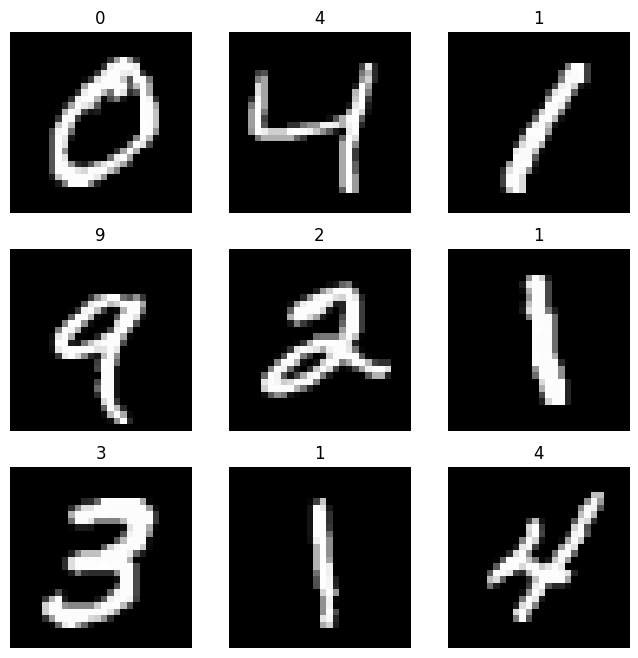

In [5]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):
    figure.add_subplot(rows, cols, i)
    plt.title(labels[i])
    plt.axis('off')
    plt.imshow(images[i], cmap='gray')

plt.show()

#### CIFAR-10

In [6]:
CIFAR_meta = unpickle('CIFAR-10/batches.meta') 
label_names = CIFAR_meta[b'label_names']

for i in range(10):
    print('label '+ str(i) + ' = ' + label_names[i].decode('utf-8'))

label 0 = airplane
label 1 = automobile
label 2 = bird
label 3 = cat
label 4 = deer
label 5 = dog
label 6 = frog
label 7 = horse
label 8 = ship
label 9 = truck


In [7]:
CIFAR_batches = []

for i in range(1, 6):
    batch = unpickle(f'CIFAR-10/data_batch_{i}')
    CIFAR_batches.append(batch)

CIFAR_test = unpickle('CIFAR-10/test_batch')


C:\Users\teoju\AppData\Local\Temp\ipykernel_1844\356563355.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


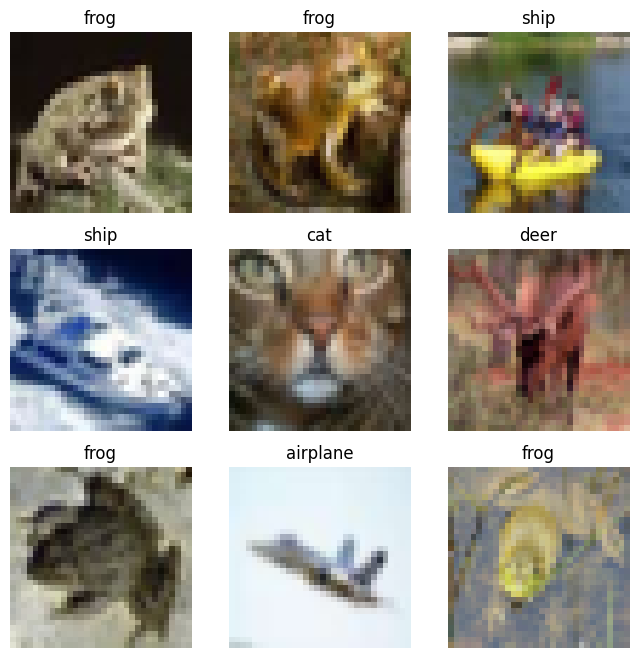

In [8]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
training_data = CIFAR_batches[1]

for i in range(1, cols * rows + 1):
    img, label = training_data[b'data'][i], training_data[b'labels'][i]
    figure.add_subplot(rows, cols, i)

    plt.title(label_names[label].decode('utf-8'))
    plt.axis("off")
    plt.imshow(img.reshape(3, 32, 32).transpose(1, 2, 0)) 
    # transpose로 matplotlib이 인식하는 형태로 변경: Channel 뒤로 빼기

plt.show()

### Custom Dataset (Class)
- https://docs.pytorch.org/vision/stable/datasets.html
- Parent: Pytorch Dataset Class
- Child: Custom Class

#### MNIST

- init: 
  - self.img / self.labels
    - data_dir = 'MNIST/' 
      - if train = True -> labels: train-labels | imgs: train-images
      - if train = False -> labels: t10k-labels | imgs: t10k-images
  - self.transform (for img)
  - self.target_transform (for label)

In [9]:
transform = transforms.Compose([
    transforms.ToTensor() # Convert a PIL Image or ndarray to tensor and scale the values accordingly.
])

In [10]:
class MNIST_Dataset(Dataset):
    def __init__(self, data_dir, train=True, transform=None, target_transform=None):
        split = 'train' if train else 't10k'

        with open(os.path.join(data_dir, f'{split}-images.idx3-ubyte'), 'rb') as f:
            self.img = np.frombuffer(f.read(), dtype=np.uint8, offset=16).reshape(-1, 28, 28).copy()

        with open(os.path.join(data_dir, f'{split}-labels.idx1-ubyte'), 'rb') as f:
            self.labels = np.frombuffer(f.read(), dtype=np.uint8, offset=8).astype(np.int64).copy()

        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.img[idx]
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)

        return image, label

In [11]:
MNIST_train = MNIST_Dataset(data_dir='MNIST', train=True, transform=transform)
MNIST_test = MNIST_Dataset(data_dir='MNIST', train=False, transform=transform)

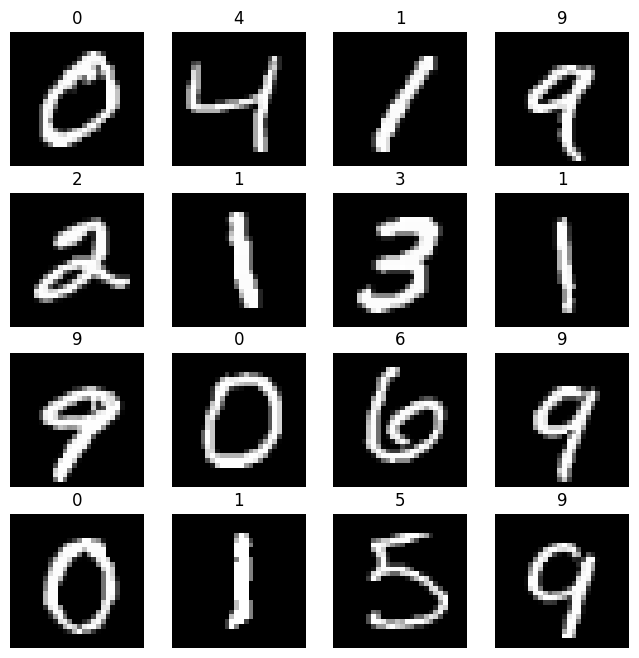

In [12]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 4, 4

for i in range(1, cols * rows + 1):
    figure.add_subplot(rows, cols, i)
    if i <= cols * rows / 2:
        plt.title(MNIST_train.labels[i])
        plt.axis('off')
        plt.imshow(MNIST_train.img[i], cmap='gray')
    else:
        plt.title(MNIST_test.labels[i])
        plt.axis('off')
        plt.imshow(MNIST_test.img[i], cmap='gray')

plt.show()

#### CIFAR-10

- init: 
  - self.img / self.labels
    - data_dir = 'CIFAR-10/' 
      - if train = True -> data_batch_n
      - if train = False -> test_batch
  - self.transform (for img)
  - self.target_transform (for label)

In [13]:
class CIFAR_Dataset(Dataset):
    def __init__(self, data_dir, train=True, transform=None, target_transform=None):
        img_list    = []
        labels_list = []

        if train:
            for i in range(1, 6):
                batch = unpickle(os.path.join(data_dir, f'data_batch_{i}'))
                img_list.append(batch[b'data'])
                labels_list.extend(batch[b'labels'])      
        else:
            batch = unpickle(os.path.join(data_dir, 'test_batch'))
            img_list.append(batch[b'data'])
            labels_list.extend(batch[b'labels'])          

        self.img    = np.concatenate(img_list, axis=0)           
        self.labels = np.array(labels_list, dtype=np.int64)       

        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.img[idx].reshape(3, 32, 32).transpose(1, 2, 0)
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)

        return image, label

In [14]:
CIFAR_train = CIFAR_Dataset(data_dir='CIFAR-10', train=True, transform=transform)
CIFAR_test = CIFAR_Dataset(data_dir='CIFAR-10', train=False, transform=transform)

C:\Users\teoju\AppData\Local\Temp\ipykernel_1844\356563355.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


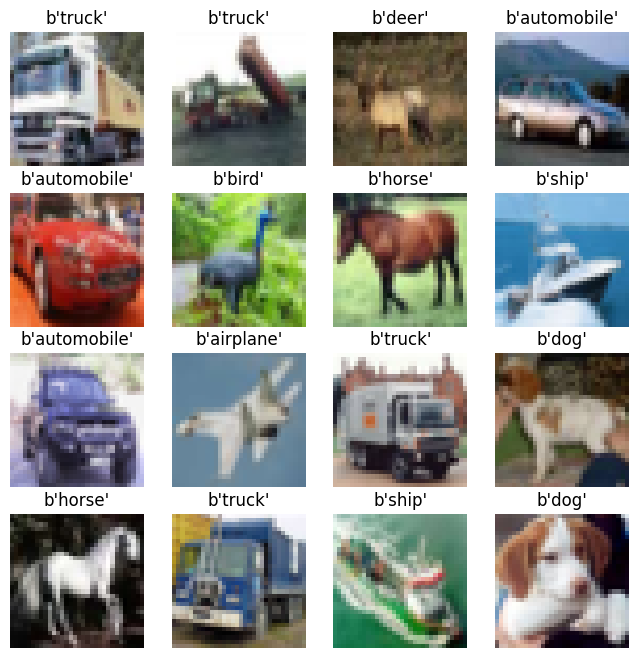

In [15]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 4, 4

for i in range(1, cols * rows + 1):
    figure.add_subplot(rows, cols, i)
    if i <= cols * rows / 2:
        plt.title(label_names[CIFAR_train.labels[i]])
        plt.axis('off')
        plt.imshow(CIFAR_train.img[i].reshape(3, 32, 32).transpose(1,2,0))
    else:
        plt.title(label_names[CIFAR_test.labels[i]])
        plt.axis('off')
        plt.imshow(CIFAR_test.img[i].reshape(3, 32, 32).transpose(1,2,0))

plt.show()

### Train: MNIST

#### Models
- torch.nn
- ResNet18
- ~~VGG~~

#### torch.nn
- batch size = 64
- 28*28 - 512 - 10 layers, ReLU
- Crosse Entropy Loss
- SGD

In [35]:
train_dataloader = DataLoader(MNIST_train, batch_size=64)
test_dataloader = DataLoader(MNIST_test, batch_size=64)

In [36]:
# Vanilla NN from Pytorch Tutorial
class NeuralNetwork(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = torch.nn.Flatten()
        self.linear_relu_stack = torch.nn.Sequential(
            torch.nn.Linear(28*28, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()

In [37]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [38]:
learning_rate = 1e-3
batch_size = 64
epochs = 10

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [39]:
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.292746  [   64/60000]
loss: 2.285425  [ 6464/60000]
loss: 2.295907  [12864/60000]
loss: 2.282206  [19264/60000]
loss: 2.280806  [25664/60000]
loss: 2.281202  [32064/60000]
loss: 2.276344  [38464/60000]
loss: 2.275837  [44864/60000]
loss: 2.264290  [51264/60000]
loss: 2.261310  [57664/60000]
Test Error: 
 Accuracy: 40.1%, Avg loss: 2.256274 

Epoch 2
-------------------------------
loss: 2.249210  [   64/60000]
loss: 2.239298  [ 6464/60000]
loss: 2.256764  [12864/60000]
loss: 2.222563  [19264/60000]
loss: 2.234315  [25664/60000]
loss: 2.232590  [32064/60000]
loss: 2.214226  [38464/60000]
loss: 2.231186  [44864/60000]
loss: 2.201378  [51264/60000]
loss: 2.193385  [57664/60000]
Test Error: 
 Accuracy: 56.4%, Avg loss: 2.190917 

Epoch 3
-------------------------------
loss: 2.183806  [   64/60000]
loss: 2.166825  [ 6464/60000]
loss: 2.196567  [12864/60000]
loss: 2.130774  [19264/60000]
loss: 2.158145  [25664/60000]
loss: 2.152641  [32064/600

#### ResNet

- Resnet model의 구조상 (torch.nn과는 달리) Input data의 추가적인 transformation 필요

In [40]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(224),                      # ResNet: 224×224 최적화
    transforms.Grayscale(num_output_channels=3), # ResNet conv1: 3ch 요구
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [41]:
MNIST_train_resnet = MNIST_Dataset(data_dir='MNIST', train=True,  transform=train_transform)
MNIST_test_resnet  = MNIST_Dataset(data_dir='MNIST', train=False, transform=train_transform)

MNIST_train_dataloader_resnet = DataLoader(MNIST_train_resnet, batch_size=64, shuffle=True)
MNIST_test_dataloader_resnet  = DataLoader(MNIST_test_resnet,  batch_size=64, shuffle=False)

In [42]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_MNIST_resnet18 = resnet18(weights=None) # Non-pretrained
model_MNIST_resnet18.fc = torch.nn.Linear(512, 10)  # 출력층만 교체 (1000 → 10클래스)
model_MNIST_resnet18 = model_MNIST_resnet18.to(device) # 어디까지 CPU로 가능하고, 어디서부터 CUDA를 사용해야?

In [43]:
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()                          # BatchNorm, Dropout을 학습 모드로 전환
    size = len(dataloader.dataset)

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device) # 데이터를 model과 동일 device로 이동

        optimizer.zero_grad()              # 이전 배치의 gradient 초기화
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()                    # gradient 계산
        optimizer.step()                   # 파라미터 업데이트

        if batch % 100 == 0:
            print(f'loss: {loss.item():.4f}  [{batch * len(X):>5d}/{size:>5d}]')


def test_loop(dataloader, model, loss_fn):
    model.eval()                           # BatchNorm, Dropout을 평가 모드로 전환
    size        = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():                  # gradient 계산 비활성화 (메모리, 속도)
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred       = model(X)
            test_loss += loss_fn(pred, y).item()
            correct   += (pred.argmax(1) == y).type(torch.float).sum().item()

    print(f'Accuracy: {correct / size * 100:.1f}%,  '
          f'Avg loss: {test_loss / num_batches:.4f}\n')


In [45]:
# torch.nn과 동일한 세팅
learning_rate = 1e-3
batch_size = 64

# epoch 수는 줄여서, 5이하
epochs = 3

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_MNIST_resnet18.parameters(), lr=learning_rate)

In [46]:
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(MNIST_train_dataloader_resnet, model_MNIST_resnet18, loss_fn, optimizer)
    test_loop(MNIST_test_dataloader_resnet, model_MNIST_resnet18, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.4482  [    0/60000]
loss: 0.0416  [ 6400/60000]
loss: 0.0480  [12800/60000]
loss: 0.0349  [19200/60000]
loss: 0.1310  [25600/60000]
loss: 0.0342  [32000/60000]
loss: 0.0515  [38400/60000]
loss: 0.0339  [44800/60000]
loss: 0.0435  [51200/60000]
loss: 0.0792  [57600/60000]
Accuracy: 97.9%,  Avg loss: 0.0750

Epoch 2
-------------------------------
loss: 0.0128  [    0/60000]
loss: 0.1906  [ 6400/60000]
loss: 0.0396  [12800/60000]
loss: 0.0660  [19200/60000]
loss: 0.0165  [25600/60000]
loss: 0.0721  [32000/60000]
loss: 0.0175  [38400/60000]
loss: 0.0183  [44800/60000]
loss: 0.0290  [51200/60000]
loss: 0.1004  [57600/60000]
Accuracy: 99.1%,  Avg loss: 0.0285

Epoch 3
-------------------------------
loss: 0.0205  [    0/60000]
loss: 0.0147  [ 6400/60000]
loss: 0.0124  [12800/60000]
loss: 0.0137  [19200/60000]
loss: 0.0565  [25600/60000]
loss: 0.0046  [32000/60000]
loss: 0.0461  [38400/60000]
loss: 0.0525  [44800/60000]
loss: 0.0007  [51200/600

In [47]:
torch.save(model_MNIST_resnet18.state_dict(), 'model_weights_MNIST_Resnet18_E3.pth')

### Train: CIFAR-10

#### Models
- torch.nn
- ResNet

#### torch.nn
- batch size = 64
- 3*32*32 - 512 - 10 layers, ReLU
- Crosse Entropy Loss
- SGD

In [16]:
CIFAR_train_dataloader = DataLoader(CIFAR_train, batch_size=64) #batch_size에 따른 영향도 한 번 test
CIFAR_test_dataloader = DataLoader(CIFAR_test, batch_size=64)

In [17]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [18]:
# Vanilla NN
class NeuralNetwork_color(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = torch.nn.Flatten()
        self.linear_relu_stack = torch.nn.Sequential(
            torch.nn.Linear(3*32*32, 512), # 3차원(RGB) 32*32 pixel 크기 color img
            torch.nn.ReLU(),
            torch.nn.Linear(512, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 10), 
            # MNIST에 비하여 INPUT DATA가 지닌 정보량이 많아서인지,
            # 단순한 구조의 NN model로는 성능이 그다지 나오지 않음. 
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [19]:
CIFAR_model = NeuralNetwork_color()

In [20]:
learning_rate = 1e-3
batch_size = 64
epochs = 10

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(CIFAR_model.parameters(), lr=learning_rate)

In [21]:
# train_loop와 test_loop는 MNIST torch.nn에서 사용한 것과 같음
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(CIFAR_train_dataloader, CIFAR_model, loss_fn, optimizer)
    test_loop(CIFAR_test_dataloader, CIFAR_model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.311942  [   64/50000]
loss: 2.297023  [ 6464/50000]
loss: 2.290883  [12864/50000]
loss: 2.291661  [19264/50000]
loss: 2.281985  [25664/50000]
loss: 2.284024  [32064/50000]
loss: 2.278811  [38464/50000]
loss: 2.280119  [44864/50000]
Test Error: 
 Accuracy: 16.3%, Avg loss: 2.269469 

Epoch 2
-------------------------------
loss: 2.289594  [   64/50000]
loss: 2.278053  [ 6464/50000]
loss: 2.247082  [12864/50000]
loss: 2.270819  [19264/50000]
loss: 2.246921  [25664/50000]
loss: 2.252539  [32064/50000]
loss: 2.256234  [38464/50000]
loss: 2.247280  [44864/50000]
Test Error: 
 Accuracy: 20.9%, Avg loss: 2.234977 

Epoch 3
-------------------------------
loss: 2.262954  [   64/50000]
loss: 2.246721  [ 6464/50000]
loss: 2.197466  [12864/50000]
loss: 2.245092  [19264/50000]
loss: 2.202835  [25664/50000]
loss: 2.208694  [32064/50000]
loss: 2.229589  [38464/50000]
loss: 2.197446  [44864/50000]
Test Error: 
 Accuracy: 23.8%, Avg loss: 2.187143 

Epoc

#### ResNet

- Resnet model의 구조상 (torch.nn과는 달리) Input data의 추가적인 transformation 필요

In [22]:
CIFAR_train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(224),                      # ResNet: 224×224 최적화
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [23]:
CIFAR_train_resnet = CIFAR_Dataset(data_dir='CIFAR-10', train=True,  transform=CIFAR_train_transform)
CIFAR_test_resnet  = CIFAR_Dataset(data_dir='CIFAR-10', train=False, transform=CIFAR_train_transform)

CIFAR_train_dataloader_resnet = DataLoader(CIFAR_train_resnet, batch_size=64, shuffle=True)
CIFAR_test_dataloader_resnet  = DataLoader(CIFAR_test_resnet,  batch_size=64, shuffle=False)

C:\Users\teoju\AppData\Local\Temp\ipykernel_1844\356563355.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_CIFAR_resnet18 = resnet18(weights=None) # Non-pretrained
model_CIFAR_resnet18.fc = torch.nn.Linear(512, 10)  # 출력층만 교체 (1000 → 10클래스)
model_CIFAR_resnet18 = model_CIFAR_resnet18.to(device) # 어디까지 CPU로 가능하고, 어디서부터 CUDA를 사용해야? -> CUDA 쓸 수 밖에...

In [25]:
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()                          # BatchNorm, Dropout을 학습 모드로 전환
    size = len(dataloader.dataset)

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device) # 데이터를 model과 동일 device로 이동

        optimizer.zero_grad()              # 이전 배치의 gradient 초기화
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()                    # gradient 계산
        optimizer.step()                   # 파라미터 업데이트

        if batch % 100 == 0:
            print(f'loss: {loss.item():.4f}  [{batch * len(X):>5d}/{size:>5d}]')


def test_loop(dataloader, model, loss_fn):
    model.eval()                           # BatchNorm, Dropout을 평가 모드로 전환
    size        = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():                  # gradient 계산 비활성화 (메모리, 속도)
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred       = model(X)
            test_loss += loss_fn(pred, y).item()
            correct   += (pred.argmax(1) == y).type(torch.float).sum().item()

    print(f'Accuracy: {correct / size * 100:.1f}%,  '
          f'Avg loss: {test_loss / num_batches:.4f}\n')


In [ ]:
# torch.nn과 동일한 세팅
learning_rate = 1e-3
batch_size = 64

# epoch 수는 30 이상
epochs = 10

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_CIFAR_resnet18.parameters(), lr=learning_rate)

In [31]:
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(CIFAR_train_dataloader_resnet, model_CIFAR_resnet18, loss_fn, optimizer)
    test_loop(CIFAR_test_dataloader_resnet, model_CIFAR_resnet18, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 1.4794  [    0/50000]
loss: 1.3787  [ 6400/50000]
loss: 1.2379  [12800/50000]
loss: 1.3469  [19200/50000]
loss: 1.3437  [25600/50000]
loss: 1.1011  [32000/50000]
loss: 1.1820  [38400/50000]
loss: 1.3716  [44800/50000]
Accuracy: 51.4%,  Avg loss: 1.3472

Epoch 2
-------------------------------
loss: 1.4973  [    0/50000]
loss: 1.2382  [ 6400/50000]
loss: 1.4794  [12800/50000]
loss: 1.2615  [19200/50000]
loss: 1.3320  [25600/50000]
loss: 1.0578  [32000/50000]
loss: 1.3062  [38400/50000]
loss: 1.3289  [44800/50000]
Accuracy: 50.2%,  Avg loss: 1.3862

Epoch 3
-------------------------------
loss: 1.4814  [    0/50000]
loss: 1.1990  [ 6400/50000]
loss: 1.2795  [12800/50000]
loss: 1.1980  [19200/50000]
loss: 1.3837  [25600/50000]
loss: 1.1814  [32000/50000]
loss: 1.2110  [38400/50000]
loss: 1.4850  [44800/50000]
Accuracy: 54.4%,  Avg loss: 1.2573

Epoch 4
-------------------------------
loss: 1.2872  [    0/50000]
loss: 1.1974  [ 6400/50000]
loss

In [ ]:
torch.save(model_CIFAR_resnet18.state_dict(), 'model_weights_CIFAR_Resnet18_E18.pth')

In [34]:
epochs = 10
optimizer = torch.optim.Adam(model_CIFAR_resnet18.parameters(), lr=learning_rate)

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(CIFAR_train_dataloader_resnet, model_CIFAR_resnet18, loss_fn, optimizer)
    test_loop(CIFAR_test_dataloader_resnet, model_CIFAR_resnet18, loss_fn)
print("Done!")

torch.save(model_CIFAR_resnet18.state_dict(), 'model_weights_CIFAR_Resnet18_E48.pth')

Epoch 1
-------------------------------
loss: 0.4866  [    0/50000]
loss: 1.9532  [ 6400/50000]
loss: 1.4965  [12800/50000]
loss: 1.1323  [19200/50000]
loss: 1.2584  [25600/50000]
loss: 1.2211  [32000/50000]
loss: 1.1863  [38400/50000]
loss: 1.1410  [44800/50000]
Accuracy: 52.9%,  Avg loss: 1.3478

Epoch 2
-------------------------------
loss: 1.3033  [    0/50000]
loss: 0.9605  [ 6400/50000]
loss: 0.8357  [12800/50000]
loss: 0.8967  [19200/50000]
loss: 0.7659  [25600/50000]
loss: 0.9946  [32000/50000]
loss: 0.8336  [38400/50000]
loss: 0.6596  [44800/50000]
Accuracy: 66.2%,  Avg loss: 1.0088

Epoch 3
-------------------------------
loss: 0.7490  [    0/50000]
loss: 0.6755  [ 6400/50000]
loss: 0.6397  [12800/50000]
loss: 0.5281  [19200/50000]
loss: 0.5828  [25600/50000]
loss: 0.7574  [32000/50000]
loss: 0.7154  [38400/50000]
loss: 0.7000  [44800/50000]
Accuracy: 73.4%,  Avg loss: 0.7629

Epoch 4
-------------------------------
loss: 0.4162  [    0/50000]
loss: 0.4893  [ 6400/50000]
loss

In [ ]:
# 모델 파라미터 불러오기
model = resnet18(weights=None)
model.fc = torch.nn.Linear(512, 10)
model.load_state_dict(torch.load('model_weights.pth'))
model.eval()

#### Tries on CIFAR-10 
- Resnet18: epochs 3 -> epochs 5 => Test Acc 50% 정도가 한계
  - epochs 수 증가 -> + epochs 10 => Acc 60% 까지는 달성
    - \+ epochs 10 with Adam Optimizer => Acc Over 80% 
  - 다른 모델을 사용
    - Resnet50은 parameter size가 너무 큼
  - fine tuning 시도